# Markov-chain LTV from zero to useful

This notebook teaches a different CLV idea from BTYD.

BTYD starts with purchase timing and asks: who is still alive, and how many future purchases should we expect?

A Markov-chain LTV model starts with **customer states** and asks:

> If customers move between states month after month, what future value should we expect from each state?

Inspiration checked: the Tensor House Markov notebook uses four states based on months of silence and projects revenue through a transition matrix. Here we tell the same idea more slowly, with data, estimation, interpretation, validation checks, and a business intervention scenario.

## 1. The idea in one sentence

A Markov chain says:

> The next state depends on the current state, not the whole past.

For LTV, a state might be:

- `New`: first month after acquisition.
- `Active`: bought this month.
- `Warm`: no purchase this month, but recently active.
- `Cooling`: longer silence.
- `Dormant`: very long silence.
- `Churned`: absorbing state, meaning we stop expecting future value.

Once we know the probability of moving between states, we can forecast future customer counts and expected profit.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704
rng = np.random.default_rng(RANDOM_SEED)

## 2. Generate a customer-month dataset

We will simulate monthly customer states for a small ecommerce brand.

Each row means:

> customer X was in state Y during month T and generated this much gross margin.

In a real project, these states come from rules built on order history, product usage, subscription status, or RFM segments.

In [2]:
states = ["New", "Active", "Warm", "Cooling", "Dormant", "Churned"]
state_to_idx = {s: i for i, s in enumerate(states)}

# True transition matrix used only to generate synthetic data.
P_true = pd.DataFrame(
    [
        [0.08, 0.58, 0.24, 0.07, 0.02, 0.01],
        [0.00, 0.62, 0.25, 0.08, 0.03, 0.02],
        [0.00, 0.34, 0.26, 0.24, 0.10, 0.06],
        [0.00, 0.18, 0.16, 0.28, 0.24, 0.14],
        [0.00, 0.08, 0.08, 0.14, 0.38, 0.32],
        [0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
    ],
    index=states,
    columns=states,
)

monthly_margin_by_state = {
    "New": 8,
    "Active": 34,
    "Warm": 16,
    "Cooling": 7,
    "Dormant": 2,
    "Churned": 0,
}

n_customers = 1800
n_months = 18
rows = []

for customer_num in range(1, n_customers + 1):
    customer_id = f"M{customer_num:05d}"
    state = "New"
    for month in range(n_months):
        margin_mean = monthly_margin_by_state[state]
        margin = 0 if margin_mean == 0 else rng.gamma(shape=3.0, scale=margin_mean / 3.0)
        rows.append({"customer_id": customer_id, "month": month, "state": state, "gross_margin": round(float(margin), 2)})
        probs = P_true.loc[state].values
        state = rng.choice(states, p=probs)

customer_month = pd.DataFrame(rows)
customer_month.head()

,customer_id,month,state,gross_margin
0,M00001,0,New,3.40
1,M00001,1,Active,23.72
2,M00001,2,Warm,15.78
3,M00001,3,Warm,25.58
4,M00001,4,Churned,0.00


In [3]:
state_counts = customer_month.pivot_table(index="month", columns="state", values="customer_id", aggfunc="count", fill_value=0)
state_counts = state_counts.reindex(columns=states, fill_value=0)
state_counts.head(10)

state,New,Active,Warm,Cooling,Dormant,Churned
month,,,,,,
0,1800,0,0,0,0,0
1,147,1059,429,108,41,16
2,12,897,465,236,107,83
3,2,753,419,255,177,194
4,0,667,346,268,208,311
5,0,594,324,237,199,446
6,0,523,312,217,182,566
7,0,485,266,202,172,675
8,0,438,241,184,157,780


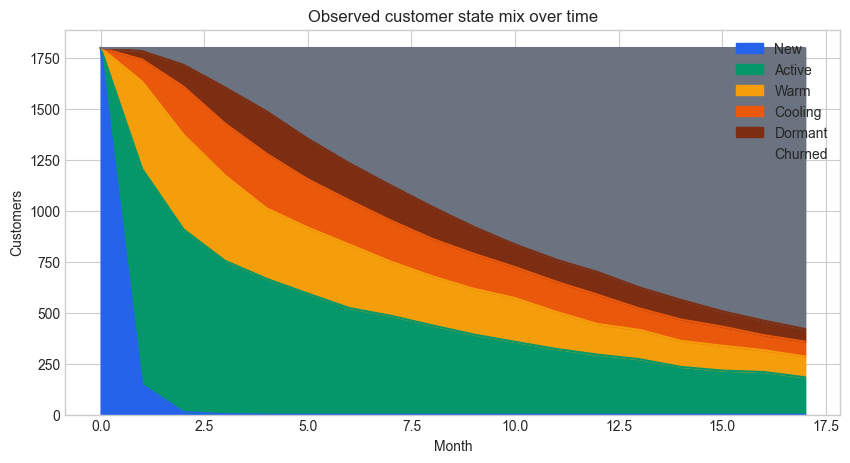

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
state_counts.plot.area(ax=ax, color=["#2563EB", "#059669", "#F59E0B", "#EA580C", "#7C2D12", "#6B7280"])
ax.set_title("Observed customer state mix over time")
ax.set_xlabel("Month")
ax.set_ylabel("Customers")
ax.legend(loc="upper right")
plt.show()

## 3. Estimate the transition matrix from data

A transition matrix has one row per current state and one column per next state.

Each row must sum to 1.

Example interpretation:

> If the `Warm -> Active` probability is 0.30, then about 30% of warm customers are expected to become active next month.

In [5]:
next_month = customer_month.copy()
next_month["month"] = next_month["month"] - 1
transitions = customer_month.merge(
    next_month[["customer_id", "month", "state"]].rename(columns={"state": "next_state"}),
    on=["customer_id", "month"],
    how="inner",
)

transition_counts = pd.crosstab(transitions["state"], transitions["next_state"]).reindex(index=states, columns=states, fill_value=0)
P_hat = transition_counts.div(transition_counts.sum(axis=1), axis=0).fillna(0)
P_hat.loc["Churned"] = [0, 0, 0, 0, 0, 1]

print("Row sums:")
display(P_hat.sum(axis=1).round(6).to_frame("row_sum"))
P_hat.round(3)

Row sums:


,row_sum
state,
New,1.0
Active,1.0
Warm,1.0
Cooling,1.0
Dormant,1.0
Churned,1.0


next_state,New,Active,Warm,Cooling,Dormant,Churned
state,,,,,,
New,0.082,0.589,0.237,0.062,0.021,0.009
Active,0.000,0.609,0.263,0.080,0.030,0.018
Warm,0.000,0.340,0.266,0.238,0.100,0.057
Cooling,0.000,0.183,0.160,0.288,0.246,0.123
Dormant,0.000,0.082,0.082,0.142,0.373,0.320
Churned,0.000,0.000,0.000,0.000,0.000,1.000


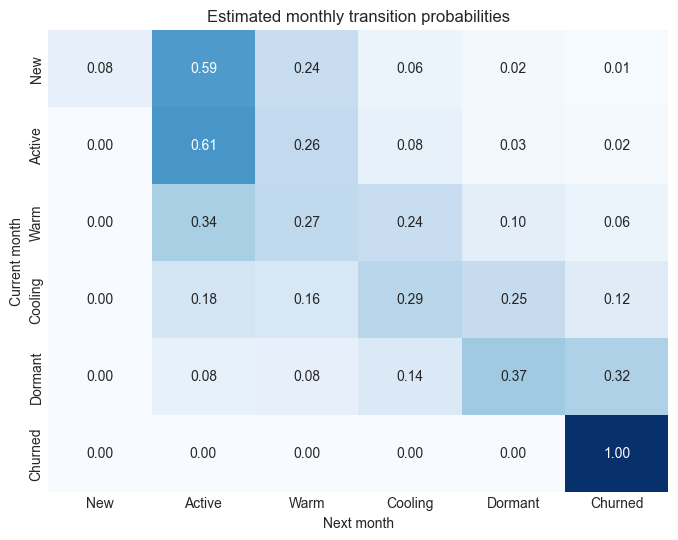

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(P_hat, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Estimated monthly transition probabilities")
ax.set_xlabel("Next month")
ax.set_ylabel("Current month")
plt.show()

## 4. Rewards: how states become money

A Markov chain tells us where customers move. LTV also needs money.

We estimate a reward vector:

> expected gross margin earned during one month in each state.

The reward can be revenue, gross margin, contribution profit, or margin minus marketing cost. For serious work, use contribution margin rather than raw revenue.

In [7]:
reward = customer_month.groupby("state")["gross_margin"].mean().reindex(states).fillna(0)
reward.loc["Churned"] = 0
reward.to_frame("expected_monthly_margin").round(2)

,expected_monthly_margin
state,
New,7.89
Active,34.03
Warm,15.93
Cooling,7.00
Dormant,1.99
Churned,0.00


## 5. Finite-horizon Markov LTV

Let `P` be the transition matrix and `r` be the reward vector.

Starting from a state today, expected value over the next `H` months is:

`r + d P r + d^2 P^2 r + ... + d^(H-1) P^(H-1) r`

where `d` is a monthly discount factor.

The formula looks intimidating, but it is just repeated forecasting:

- month 0: collect current reward.
- month 1: move customers using `P`, collect expected reward.
- month 2: move again, collect expected reward.
- repeat.

In [8]:
def finite_horizon_ltv(P, reward, horizon_months=24, monthly_discount_rate=0.01):
    P_arr = np.asarray(P, dtype=float)
    r = np.asarray(reward, dtype=float).reshape(-1, 1)
    discount = 1 / (1 + monthly_discount_rate)

    values = np.zeros((P_arr.shape[0], 1))
    state_distribution = np.eye(P_arr.shape[0])
    for t in range(horizon_months):
        values += (discount ** t) * state_distribution @ r
        state_distribution = state_distribution @ P_arr
    return pd.Series(values.ravel(), index=P.index, name=f"ltv_{horizon_months}m")

ltv_24 = finite_horizon_ltv(P_hat, reward, horizon_months=24, monthly_discount_rate=0.01)
ltv_24.to_frame().round(2)

,ltv_24m
state,
New,211.88
Active,233.21
Warm,180.99
Cooling,136.28
Dormant,85.61
Churned,0.00


In [9]:
horizons = [1, 3, 6, 12, 24, 36]
ltv_by_horizon = pd.concat(
    [finite_horizon_ltv(P_hat, reward, h, monthly_discount_rate=0.01).rename(f"{h}m") for h in horizons],
    axis=1,
)
ltv_by_horizon.round(2)

,1m,3m,6m,12m,24m,36m
state,,,,,,
New,7.89,54.24,103.67,163.81,211.88,225.14
Active,34.03,80.13,127.96,186.44,233.21,246.11
Warm,15.93,49.72,89.95,140.49,180.99,192.16
Cooling,7.00,30.09,61.98,103.19,136.28,145.41
Dormant,1.99,14.95,35.76,63.38,85.61,91.74
Churned,0.00,0.00,0.00,0.00,0.00,0.00


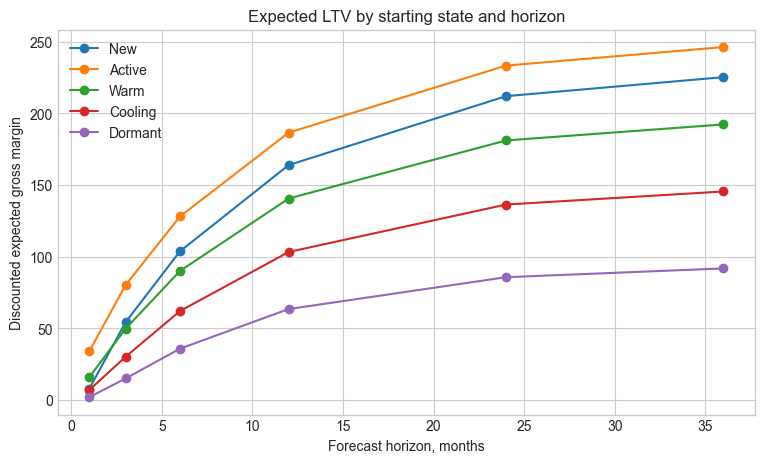

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for state in states[:-1]:
    ax.plot(horizons, ltv_by_horizon.loc[state], marker="o", label=state)
ax.set_title("Expected LTV by starting state and horizon")
ax.set_xlabel("Forecast horizon, months")
ax.set_ylabel("Discounted expected gross margin")
ax.legend()
plt.show()

## 6. Infinite-horizon shortcut

If the discount factor is below 1, we can compute discounted long-run value with a matrix inverse:

`V = (I - dP)^(-1) r`

This is the matrix version of a geometric series.

It is useful because it gives the total discounted future value from each state without manually looping through many months.

In [11]:
def infinite_horizon_ltv(P, reward, monthly_discount_rate=0.01):
    P_arr = np.asarray(P, dtype=float)
    r = np.asarray(reward, dtype=float)
    discount = 1 / (1 + monthly_discount_rate)
    I = np.eye(P_arr.shape[0])
    values = np.linalg.solve(I - discount * P_arr, r)
    return pd.Series(values, index=P.index, name="discounted_infinite_ltv")

ltv_infinite = infinite_horizon_ltv(P_hat, reward, monthly_discount_rate=0.01)
pd.concat([ltv_24, ltv_infinite], axis=1).round(2)

,ltv_24m,discounted_infinite_ltv
state,,
New,211.88,230.20
Active,233.21,251.02
Warm,180.99,196.42
Cooling,136.28,148.88
Dormant,85.61,94.07
Churned,0.00,0.00


## 7. Portfolio forecast

The same transition matrix can forecast customer counts.

If `n0` is the current number of customers in each state, then:

- next month: `n1 = n0 P`
- two months: `n2 = n0 P^2`

This is useful for finance planning because it connects LTV to customer equity: total expected value of the portfolio.

In [12]:
current_month = customer_month[customer_month["month"] == customer_month["month"].max()]
current_counts = current_month["state"].value_counts().reindex(states, fill_value=0)
current_counts.to_frame("customers_now")

,customers_now
state,
New,0
Active,183
Warm,102
Cooling,73
Dormant,62
Churned,1380


In [13]:
def forecast_counts(current_counts, P, horizon=12):
    dist = current_counts.values.astype(float).reshape(1, -1)
    rows = []
    for t in range(horizon + 1):
        rows.append(pd.Series(dist.ravel(), index=P.columns, name=t))
        dist = dist @ np.asarray(P, dtype=float)
    return pd.DataFrame(rows)

count_forecast = forecast_counts(current_counts, P_hat, horizon=12)
count_forecast.head()

next_state,New,Active,Warm,Cooling,Dormant,Churned
0,0.0,183.000000,102.000000,73.000000,62.000000,1380.000000
1,0.0,164.470485,92.008501,68.674325,56.823938,1418.022751
2,0.0,148.582525,83.361714,62.840250,52.269752,1452.945760
3,0.0,134.534291,75.577771,57.190356,47.790373,1484.907209
4,0.0,121.938762,68.542663,51.956001,43.526037,1514.036537


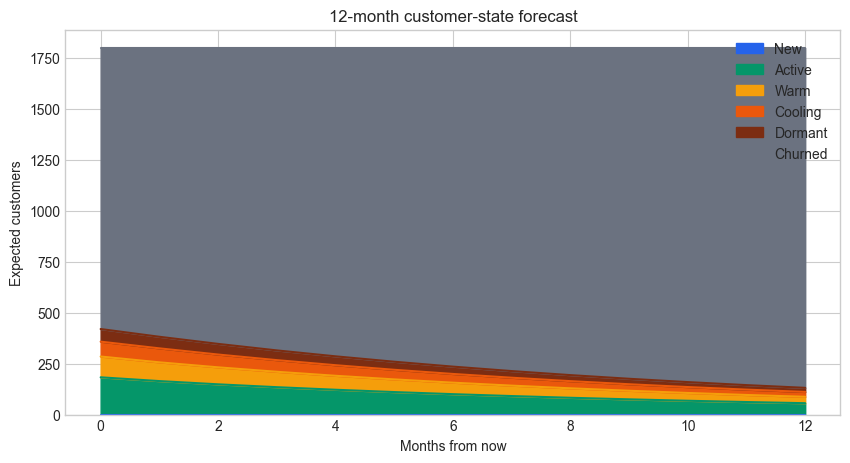

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
count_forecast[states].plot.area(ax=ax, color=["#2563EB", "#059669", "#F59E0B", "#EA580C", "#7C2D12", "#6B7280"])
ax.set_title("12-month customer-state forecast")
ax.set_xlabel("Months from now")
ax.set_ylabel("Expected customers")
ax.legend(loc="upper right")
plt.show()

In [15]:
portfolio_ltv = float(current_counts.values @ ltv_infinite.values)
print(f"Discounted expected value of current portfolio: {portfolio_ltv:,.0f}")

Discounted expected value of current portfolio: 82,673


## 8. Intervention scenario: improve dormant reactivation

Markov LTV is especially handy for scenario planning.

Suppose customer success launches a low-cost win-back campaign for `Dormant` customers. We believe it can move some probability mass from `Dormant -> Churned` into `Dormant -> Active`.

We can edit the transition matrix and reprice the portfolio.

In [16]:
P_campaign = P_hat.copy()
shift = min(0.08, P_campaign.loc["Dormant", "Churned"])
P_campaign.loc["Dormant", "Churned"] -= shift
P_campaign.loc["Dormant", "Active"] += shift

ltv_campaign = infinite_horizon_ltv(P_campaign, reward, monthly_discount_rate=0.01)
comparison = pd.DataFrame({
    "baseline_ltv": ltv_infinite,
    "campaign_ltv": ltv_campaign,
    "incremental_ltv": ltv_campaign - ltv_infinite,
}).round(2)
comparison

,baseline_ltv,campaign_ltv,incremental_ltv
state,,,
New,230.20,260.22,30.03
Active,251.02,280.97,29.95
Warm,196.42,226.83,30.41
Cooling,148.88,180.27,31.39
Dormant,94.07,144.16,50.08
Churned,0.00,0.00,0.00


In [17]:
portfolio_ltv_campaign = float(current_counts.values @ ltv_campaign.values)
incremental_portfolio_value = portfolio_ltv_campaign - portfolio_ltv
print(f"Baseline portfolio value:   {portfolio_ltv:,.0f}")
print(f"Campaign portfolio value:   {portfolio_ltv_campaign:,.0f}")
print(f"Incremental portfolio value:{incremental_portfolio_value:,.0f}")

Baseline portfolio value:   82,673
Campaign portfolio value:   96,652
Incremental portfolio value:13,979


## 9. How to explain this to a stakeholder

A practical explanation:

> We grouped customers into lifecycle states, estimated month-to-month transition probabilities, attached expected monthly margin to each state, and projected discounted future value. Active customers are valuable because they both generate margin now and have a high chance of staying productive. Dormant customers are less valuable, but if we improve reactivation, the portfolio value can increase.

This is not a causal proof. It is a planning model. To prove the campaign works, run an experiment.

## 10. Markov LTV mistakes to avoid

- **Bad state definitions.** If states do not reflect real behavior, the transition matrix is just decoration.
- **Too many states.** A huge matrix with sparse transitions is unstable.
- **Forgetting absorbing churn.** If churned customers can accidentally return in the matrix, check whether that is business reality or data leakage.
- **Assuming stationarity forever.** Transition probabilities can drift after pricing changes, seasonality, product launches, or macro shocks.
- **Using revenue instead of margin.** LTV should support decisions. Costs matter.
- **Calling scenarios causal.** Editing the matrix is a what-if calculation, not proof.

Markov-chain LTV is best when customer lifecycle states are natural and interpretable. BTYD is best when repeat purchase timing is the main signal.

## Final consultant summary

Markov-chain LTV turns customer movement into value.

The recipe is:

1. Define lifecycle states.
2. Count transitions from historical data.
3. Convert counts into probabilities.
4. Estimate profit or margin by state.
5. Project future state distributions and discounted rewards.
6. Use scenario analysis to compare actions.

A junior analyst should remember this: the transition matrix is the engine, the reward vector is the money, and discounting turns future money into present value.